# Spline

**Fits and compares linear and natural cubic spline specifications of the treatment-effect heterogeneity model for aNSCLC cohort. Both models regress 2-year RMST pseudo-observations on treatment, calibrated 6-month survival probability, and their interaction using overlap weighting. The spline model (natural cubic spline, df=3) relaxes the linearity assumption of the primary analysis, allowing the treatment-effect function TE(r) to vary flexibly across the baseline risk continuum. Intended as a sensitivity analysis to the primary heterogeneity results.**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
from statsmodels.formula.api import wls
import statsmodels.formula.api as smf
from patsy import dmatrix
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from iptw_survival import OverlapWeightSurvivalEstimator

from utils.treatment_effects import calculate_treatment_effect_curve_rmst

## Import data 

### Import calibrated survival probabilities 

In [2]:
surv_pred_df = pd.read_csv('../outputs/gb_6m_survival_predictions_calibrated.csv')

In [3]:
surv_pred_df.head(3)

,PatientID,psurv_180_calibrated
0,FF16F972863F8,0.478161
1,F5EF114860555,0.596677
2,F95B93B796545,0.935103


In [4]:
surv_pred_df.shape

(1681, 2)

### Import treatment assignment

In [5]:
treatment_df = pd.read_csv('../outputs/pembrochemo_pembro_index.csv')

In [6]:
treatment_df.shape

(20623, 3)

In [7]:
treatment_df.head(3)

,PatientID,LineName,StartDate
0,FA2BFA6104994,pembro_platinum,2019-08-19
1,F40B0A967B8AC,pembro_platinum,2020-03-13
2,F242D29EFD1F3,pembro_platinum,2024-03-08


### Import features

In [8]:
dtype_map = pd.read_csv('../outputs/pembrochemo_pembro_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
features_df = pd.read_csv('../outputs/pembrochemo_pembro_features_df.csv', dtype = dtype_map)

In [9]:
features_df.shape

(2064, 164)

### Import RMST pseudo-observations

In [10]:
pseudo_obs_df = pd.read_csv('../outputs/pseudo_obs_rmst.csv')

In [11]:
pseudo_obs_df.shape

(1681, 3)

In [12]:
pseudo_obs_df.head(3)

,PatientID,rmst_pseudo_1y,rmst_pseudo_2y
0,FF16F972863F8,299.446640,283.129363
1,F5EF114860555,159.475543,149.676630
2,F95B93B796545,368.006492,743.998856


### Merge dataframes

In [13]:
df = pd.merge(features_df, surv_pred_df, on = 'PatientID', how = 'left')

In [14]:
df.shape

(2064, 165)

In [15]:
df = pd.merge(df, pseudo_obs_df, on = 'PatientID', how = 'left')

In [16]:
df.shape

(2064, 167)

In [17]:
df = pd.merge(df, treatment_df, on = 'PatientID', how = 'left')

In [18]:
df.shape

(2064, 169)

In [19]:
df = df.query('adv_diagnosis_year <= 2023')

In [20]:
df.shape

(1681, 169)

## Calculating overlap weights

In [21]:
df['treatment'] = np.where(df['LineName'] == 'pembro_platinum', 1, 0)

In [22]:
df.treatment.value_counts()

treatment
0    1096
1     585
Name: count, dtype: int64

In [23]:
estimator = OverlapWeightSurvivalEstimator(normalize = None)

In [24]:
estimator.fit(df = df,
              treatment_col = 'treatment',
              cat_var = ['Histology', 'SmokingStatus'],
              cont_var = ['days_diagnosis_to_adv', 'GroupStage_mod', 'ecog_index', 'ses_mod', 'age', 'percent_change_weight', 'hemoglobin', 'albumin', 'total_bilirubin', 'creatinine', 'van_walraven_score'],
              binary_var = ['sex_male', 'ecog_index_na', 'ses_mod_na', 'medicaid', 'before_2020', 'days_to_treatment_before_30d'],
              lr_kwargs = {
                  'class_weight': 'balanced',
                  'solver': 'lbfgs',
                  'penalty': 'l2',
                  'max_iter': 1000,
                  'random_state': 42
              },
              clip_bounds = (0.01, 0.99),
              stabilized = False,
              use_missing_flags = False)

In [25]:
overlap_df = estimator.transform()

## WLS model

In [26]:
# Create grid of psurv_180 values (5th to 95th percentile)
psurv_grid = np.linspace(
    overlap_df['psurv_180_calibrated'].quantile(0.05),
    overlap_df['psurv_180_calibrated'].quantile(0.95),
    200
)

In [27]:
formula_2y = 'rmst_pseudo_2y ~ treatment * psurv_180_calibrated'

model_2y = wls(
    formula = formula_2y,
    data = overlap_df,
    weights = overlap_df['overlap_weight']
).fit(cov_type = 'HC3')

print(model_2y.summary())

                            WLS Regression Results                            
Dep. Variable:         rmst_pseudo_2y   R-squared:                       0.198
Model:                            WLS   Adj. R-squared:                  0.196
Method:                 Least Squares   F-statistic:                     128.2
Date:                Fri, 01 May 2026   Prob (F-statistic):           9.69e-75
Time:                        21:16:06   Log-Likelihood:                -11849.
No. Observations:                1681   AIC:                         2.371e+04
Df Residuals:                    1677   BIC:                         2.373e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [28]:
# Create spline basis
spline_basis = dmatrix(
    "cr(psurv_180_calibrated, df=3) - 1", 
    {"psurv_180_calibrated": df['psurv_180_calibrated']}
)

# Add to dataframe
df_spline = overlap_df.copy()
df_spline['spline_0'] = spline_basis[:, 0]
df_spline['spline_1'] = spline_basis[:, 1]
df_spline['spline_2'] = spline_basis[:, 2]

# Fit spline model with explicit terms
model_spline = smf.wls(
    'rmst_pseudo_2y ~ treatment + spline_0 + spline_1 + spline_2 + '
    'treatment:spline_0 + treatment:spline_1 + treatment:spline_2',
    data=df_spline,
    weights=df_spline['overlap_weight']
).fit(cov_type = 'HC3')

In [29]:
# Calculate treatment effects for SPLINE model
# Need to create spline basis for prediction grid
spline_basis_grid = dmatrix(
    "cr(psurv_180_calibrated, df=3) - 1",
    {"psurv_180_calibrated": psurv_grid}
)

# Create prediction dataframes for treatment effect calculation
pred_grid_0 = pd.DataFrame({
    'treatment': 0,
    'spline_0': spline_basis_grid[:, 0],
    'spline_1': spline_basis_grid[:, 1],
    'spline_2': spline_basis_grid[:, 2]
})

pred_grid_1 = pd.DataFrame({
    'treatment': 1,
    'spline_0': spline_basis_grid[:, 0],
    'spline_1': spline_basis_grid[:, 1],
    'spline_2': spline_basis_grid[:, 2]
})

# Get predictions with confidence intervals
pred_0 = model_spline.get_prediction(pred_grid_0)
pred_1 = model_spline.get_prediction(pred_grid_1)

# Calculate treatment effect (difference)
effect_2y_spline = pd.DataFrame({
    'baseline': psurv_grid,
    'treatment_effect': pred_1.predicted_mean - pred_0.predicted_mean,
    'ci_lower': pred_1.conf_int()[:, 0] - pred_0.conf_int()[:, 1],
    'ci_upper': pred_1.conf_int()[:, 1] - pred_0.conf_int()[:, 0]
})

In [30]:
# Calculate treatment effects using the utils function
effect_2y_df = calculate_treatment_effect_curve_rmst(
    model = model_2y,
    baseline_var = 'psurv_180_calibrated',
    baseline_values = psurv_grid
)

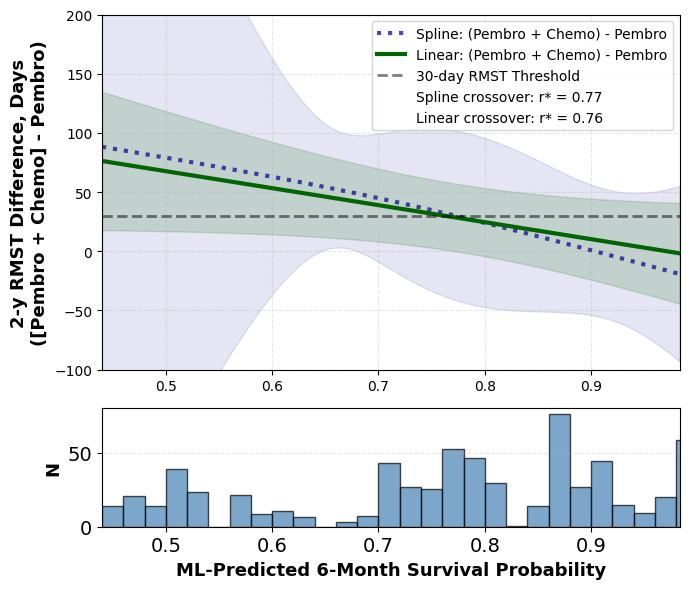

In [31]:
# Plot treatment effect - comparing both models
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), gridspec_kw={'height_ratios': [3, 1]})

# Plot spline model
ax1.plot(effect_2y_spline['baseline'], effect_2y_spline['treatment_effect'], 
         linewidth=3, color='darkblue', label='Spline: (Pembro + Chemo) - Pembro',
         linestyle=':', alpha=0.7)

ax1.fill_between(effect_2y_spline['baseline'], 
                 effect_2y_spline['ci_lower'], 
                 effect_2y_spline['ci_upper'], 
                 alpha=0.1, color='darkblue')

# Plot linear model
ax1.plot(effect_2y_df['baseline'], effect_2y_df['treatment_effect'], 
         linewidth = 3, color = 'darkgreen', label = 'Linear: (Pembro + Chemo) - Pembro')

ax1.fill_between(effect_2y_df['baseline'], effect_2y_df['ci_lower'], effect_2y_df['ci_upper'], 
                 alpha = 0.15, color = 'darkgreen')

ax1.axhline(y = 30, color = 'black', linestyle = '--', linewidth = 2, alpha = 0.5, label = '30-day RMST Threshold')

# Find crossover point where treatment effect crosses 30 days
crossover_value = 30

# Find where spline treatment effect crosses the threshold
te = effect_2y_spline['treatment_effect'].values
baseline = effect_2y_spline['baseline'].values

# Find indices where TE crosses the threshold
crossing_indices = np.where(np.diff(np.sign(te - crossover_value)))[0]

if len(crossing_indices) > 0:
    # Interpolate for precision
    idx = crossing_indices[-1]
    x0, x1 = baseline[idx], baseline[idx + 1]
    y0, y1 = te[idx], te[idx + 1]
    # Linear interpolation between the two grid points straddling the crossing
    crossover_survival_estimate_spline = x0 + (crossover_value - y0) * (x1 - x0) / (y1 - y0)
else:
    crossover_survival_estimate_spline = None
    print("No crossover point found within observed range")

# Calculate crossover point algebraically: TE(r) = beta1 + beta3*r = crossover_value
# Solving for r: r = (crossover_value - beta1) / beta3
beta1 = model_2y.params['treatment']
beta3 = model_2y.params['treatment:psurv_180_calibrated']
crossover_survival_estimate_linear = (crossover_value - beta1) / beta3

# Add invisible proxy artists for crossover points
proxy_spline = Line2D([0], [0], color='none', 
                       label=f'Spline crossover: r* = {crossover_survival_estimate_spline:.2f}')
proxy_linear = Line2D([0], [0], color='none', 
                       label=f'Linear crossover: r* = {crossover_survival_estimate_linear:.2f}')

handles, labels = ax1.get_legend_handles_labels()
ax1.legend(handles=handles + [proxy_spline, proxy_linear], 
           fontsize=10, loc='upper right')

ax1.set_ylabel('2-y RMST Difference, Days\n([Pembro + Chemo] - Pembro)', 
               fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_xlim([psurv_grid.min(), psurv_grid.max()])
ax1.set_ylim(-100, 200)

# Bottom panel - histogram
ax2.hist(overlap_df['psurv_180_calibrated'], 
         bins=50,
         weights=overlap_df['overlap_weight'],
         alpha=0.7, 
         edgecolor='black', 
         color='steelblue')

ax2.set_xlabel('ML-Predicted 6-Month Survival Probability', fontsize = 13, fontweight = 'bold')
ax2.set_ylabel('N', fontsize = 13, fontweight = 'bold')
ax2.set_xlim([psurv_grid.min(), psurv_grid.max()])
ax2.grid(alpha = 0.3, linestyle = '--', axis = 'y')
ax2.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.savefig('../outputs/spline.pdf', format = 'pdf', bbox_inches = 'tight')
plt.show()